<a href="https://colab.research.google.com/github/yastreb13/dzdlmfti/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22AI_Edu_Modern_CV_Homework_3%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 3. Детекция объектов

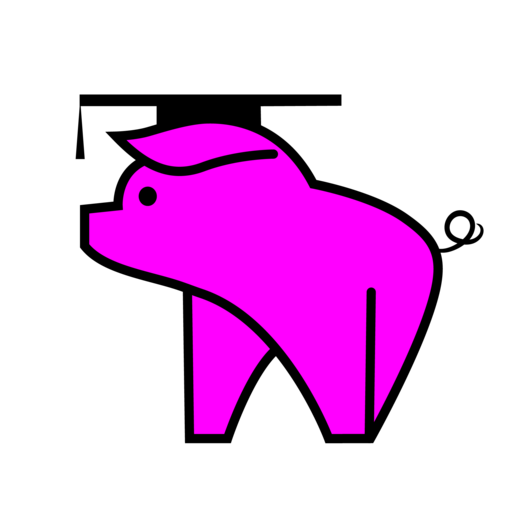


Сыграем в квиддич? Или лучше в карты?

В этом дз вам предстоит написать практически с нуля архитектуру для детекции, а также воспользоваться готовым решением. На выбор даётся два датасета, отличаются они только картинками. Форматы, баллы - все одинаково.

Первый вариант это датасет по кадрам игры в квиддич из Гарри Поттера. Если вы забыли правила, то нажмите [сюда](https://harrypotter.fandom.com/ru/wiki/%D0%9A%D0%B2%D0%B8%D0%B4%D0%B4%D0%B8%D1%87). Вы научитесь искать и выделять на фотографиях бладжеры, квоффл и снитч.

Второй вариант это датасет с игральными картами. Если вы забыли что такое карты, то нажмите [сюда](https://ru.wikipedia.org/wiki/%D0%98%D0%B3%D1%80%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B5_%D0%BA%D0%B0%D1%80%D1%82%D1%8B). Вы научитесь искать и выделять на фотографиях несколько типов карт.

Оба варианта содержат около 300 картинок, данные хранятся в xml в формате PascalVOC. Есть малые отличия, но ничего страшного.


Если с самописным детектором совсем не получается, то можно после создания датасетов перейти к концу, где обучается готовый, с ним будет проще :)

# Notes

Дз проверялось на работоспособность в colab. Не гарантируется, что будет работать на чем-то другом. На Windows, скорее всего, вас ждет немало проблем :(

По вопросам формулировок (не ошибок торча!), в случае отсутствия ответа в общем чате (поиск по чату позволяет проверить), можно написать в него с тегом @markblumenau.

## Данные

Скачайте один из датасетов на свой вкус и начните работу с ним.
Разметка находится в xmls папке, картинки в images.

In [60]:
# Harry Potter -- uncomment
#!wget https://github.com/aiedu-courses/datasets/blob/main/computer_vision/harry/data.zip

In [1]:
!wget https://github.com/aiedu-courses/datasets/blob/main/computer_vision/cards/data.zip?raw=true

--2026-08-21 11:05:52--  https://github.com/aiedu-courses/datasets/blob/main/computer_vision/cards/data.zip?raw=true
Resolving github.com (github.com)... 20.29.134.23
Connecting to github.com (github.com)|20.29.134.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/aiedu-courses/datasets/raw/refs/heads/main/computer_vision/cards/data.zip [following]
--2026-08-21 11:05:53--  https://github.com/aiedu-courses/datasets/raw/refs/heads/main/computer_vision/cards/data.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/aiedu-courses/datasets/refs/heads/main/computer_vision/cards/data.zip [following]
--2026-08-21 11:05:53--  https://raw.githubusercontent.com/aiedu-courses/datasets/refs/heads/main/computer_vision/cards/data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connec

In [2]:
!unzip "data.zip?raw=true"

Archive:  data.zip?raw=true
   creating: data/
   creating: data/images/
   creating: data/xmls/
  inflating: data/class_dict         
  inflating: data/images/IMG_2603.JPG  
  inflating: data/images/IMG_2617.JPG  
  inflating: data/images/IMG_2398.JPG  
  inflating: data/images/IMG_2401.JPG  
  inflating: data/images/IMG_2415.JPG  
  inflating: data/images/IMG_2429.JPG  
  inflating: data/images/IMG_2561.JPG  
  inflating: data/images/IMG_2549.JPG  
  inflating: data/images/IMG_2548.JPG  
  inflating: data/images/cam_image48.jpg  
  inflating: data/images/IMG_2560.JPG  
  inflating: data/images/IMG_2574.JPG  
  inflating: data/images/IMG_2428.JPG  
  inflating: data/images/IMG_2414.JPG  
  inflating: data/images/IMG_2400.JPG  
  inflating: data/images/IMG_2399.JPG  
  inflating: data/images/IMG_2616.JPG  
  inflating: data/images/IMG_2602.JPG  
  inflating: data/images/IMG_2614.JPG  
  inflating: data/images/IMG_2600.JPG  
  inflating: data/images/IMG_2628.JPG  
  inflating: data/imag

# Задача 1. 0.5 балла.

Ниже написан код для стандартного Dataset из библиотеки pytorch. Dataset требует реализации `__getitem__` и `__len__` методов. Далее эти методы будут использованы для формирования батчей для обучения. Поскольку читать придется из xml файлов, нужно перед этим дописать функцию `get_xml_data`, чтобы по названию картинки подтягивать аннотации.

In [3]:
import torch
import torch.nn.functional as F
from xml.etree import ElementTree as ET
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from pathlib import Path
import glob
import numpy as np
from PIL import Image
import torchvision
from torchvision.models import ResNet50_Weights
from tqdm.notebook import tqdm
from torch import nn
import shutil
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

Функции можно и нужно передать некий class_dict. Он есть и при инициализации датасета ниже. С его помощью можно название класса превратить в int. Далее подразумевается, что класс идёт как int.

In [64]:
import pandas
pandas.read_xml('/content/data/xmls/IMG_2383.xml')

,folder,filename,path,database,width,height,depth,segmented,name,pose,truncated,difficult,bndbox
0,test,None,None,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None
1,None,IMG_2383.JPG,None,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None
2,None,None,C:\tensorflow_cards\test\IMG_2383.JPG,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None
3,None,None,None,Unknown,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None
4,None,None,None,None,378.0,504.0,3.0,NaN,None,None,NaN,NaN,None
5,None,None,None,None,NaN,NaN,NaN,0.0,None,None,NaN,NaN,None
6,None,None,None,None,NaN,NaN,NaN,NaN,ace,Unspecified,0.0,0.0,\n\t\t\t


In [4]:
def get_xml_data(image_name, root, class_dict, xml_prefix="/xmls/"):
    # get smth like ZZZ/YYY/XXXXXX.jpg -> XXXXXX
    filename = image_name.split("/")[-1].split(".")[0]
    # read xml
    tree = ET.parse(str(root) + xml_prefix + filename + ".xml")
    treeroot = tree.getroot()
    # iterate over bboxes
    bboxes = []
    for member in treeroot.findall("object"):
        # you need: xmin ymin xmax ymax, class in dict
        # то есть res выглядит как [xmin, ymin, xmax, ymax, class]
        # всё в int!
        # Для корректной работы клеточек ниже требуется конкретная последовательность координат
        # См. доку https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/
        # Нас интересует pascal_voc формат, далее применяется он.
        name=member.find("name").text
        xmin=int(float(member.find("bndbox/xmin").text))
        xmax=int(float(member.find("bndbox/xmax").text))
        ymin=int(float(member.find("bndbox/ymin").text))
        ymax=int(float(member.find("bndbox/ymax").text))
        class_id=class_dict[name]
        res=[xmin,ymin,xmax,ymax,class_id]
        bboxes.append(res)

    return bboxes

In [5]:
class PascalDataset(torch.utils.data.Dataset):
    def __init__(self, *, transform, root="dataset", train=True, seed=42):
        self.root = Path(root)
        self.transform = transform

        assert self.root.is_dir(), f"No data at `{root}`"

        self.filenames = np.array(glob.glob(root + "/images/*"))
        with open(str(self.root) + "/class_dict", "r") as f:
            self.class_dict = eval(f.readline())

        self.class_dict_inv = {v: k for k, v in self.class_dict.items()}

        np.random.seed(seed)
        permutation = np.random.permutation(len(self.filenames))

        # Train/test split
        if train:
            self.filenames = self.filenames[
                permutation[: int(len(self.filenames) * 0.9)]
            ].tolist()
        else:
            self.filenames = self.filenames[
                permutation[int(len(self.filenames) * 0.9) :]
            ].tolist()

    def __getitem__(self, idx):
        # Нужно обладая файлнеймом подгрузить картинку и бибоксы, функцию для подгрузки бибоксов вы дописали выше :)
        fname = self.filenames[idx]
        image = np.array(Image.open(fname).convert('RGB'))
        bboxes = get_xml_data(fname, self.root, self.class_dict) # Changed from self.class_dict_inv to self.class_dict

        # transform будут объявлены ниже за вас
        # Но библиотека привередлива к формату данных на входе, внимательно прочтите прошлую клеточку
        return self.transform(image=image, bboxes=bboxes)

    def __get_raw_item__(self, idx):
        fname = self.filenames[idx]
        return fname, get_xml_data(fname, self.root, self.class_dict)

    def __len__(self):
        ### YOUR CODE HERE ###
        return len(self.filenames)

Ниже определяем стандартные нормализации и приведение размера к 512x512.


In [33]:
pip install albumentations

In [34]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [7]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.Resize(512, 512),
        # теперь называется так
        A.Normalize(mean=mean, std=std),

        ToTensorV2(),
    ],
    # Вот тут мы говорим что хотим pascal_voc
    bbox_params=dict(format="pascal_voc", min_visibility=0.3),
)

test_transform = A.Compose(
    [
        A.Resize(512, 512),
        #A.augmentations.transforms.Normalize(mean=mean, std=std),
        A.Normalize(mean=mean,std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.5),
)

In [8]:
train_ds = PascalDataset(root="./data/", transform=train_transform, train=True)
test_ds = PascalDataset(root="./data/", transform=test_transform, train=False)

In [9]:
train_ds

# Задача 2. 1 балл.

Теперь, когда мы загрузили данные, хорошо бы посмотреть на них, прежде чем обучать какие-либо модели. Напишите функцию `visualize`, которая принимает списки изображений и прямоугольников в качестве входных данных и рисует эти прямоугольники на изображениях.

В датасете есть class_dict_inv, который позволит вам сделать обратное преобразование: int, содержащий класс, в строку с названием.


Полезные функции:
* [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) -- легко создавать несколько изображений в одной pyplot figure
* [ax.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) -- отображение графиков (не забудьте откатить нормализацию)
* [ax.text](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html), [patches.Rectangle](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html) -- для рисования прямоугольников и текста с аннотацией

In [35]:
import matplotlib.patches as patches

In [36]:
def visualize(images, bboxes):
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

    fig, axes = plt.subplots(
        2, len(images) // 2 + len(images) % 2, figsize=(10, 8), dpi=100
    )

    for i, ax in enumerate(axes.reshape(-1)):

        ax.axis(False)

        if i >= len(images):
            break
        # Вот тут нужно выполнить permute (вспомните где у torch каналы, а где они у matplotlib)
        # И откатить нормализацию (просто обратное преобразование)
        # Имена и количества классов можно подтянуть из датасета через train_ds.class_dict_inv
        img=images[i].permute(1,2,0)
        mean=torch.tensor(mean).view(1,1,3)
        std=torch.tensor(std).view(1,1,3)
        abnormal_image=img*std+mean
        # Вот тут покажите картинку после отката нормализации
        ax.imshow(abnormal_image)

        for bbox in bboxes[i]:
            x_min,y_min, x_max, y_max, class_id=bbox
            height=(y_max-y_min)
            width=(x_max-x_min)
            # Создаем прямоугольник, передавая (x_min, y_min), ширину и высоту
            rect = patches.Rectangle((x_min, y_min), width, height, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x_min, y_min-5, train_ds.class_dict_inv[class_id], color='red')

У вас должно получиться что-то похожее на изображения для датасета с масками:

![image](https://i.imgur.com/V5TUT26.png)

/tmp/ipykernel_461/2009817816.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean=torch.tensor(mean).view(1,1,3)
/tmp/ipykernel_461/2009817816.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std=torch.tensor(std).view(1,1,3)


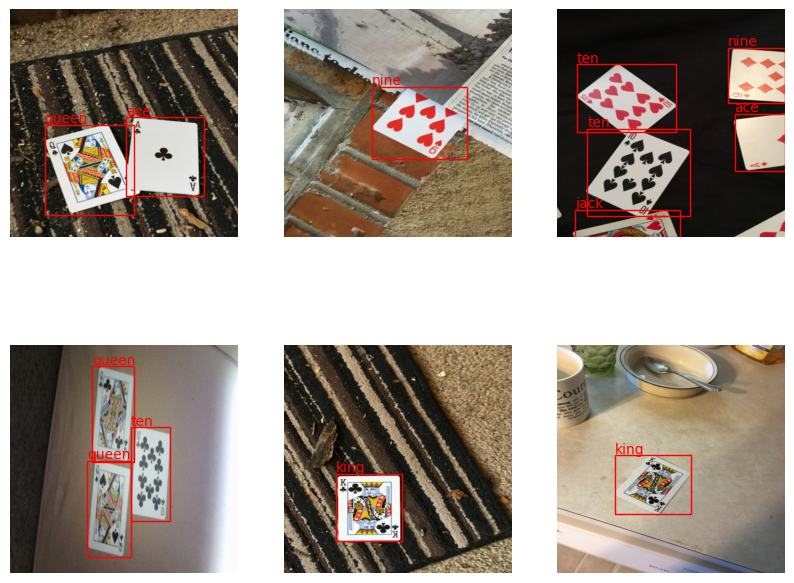

In [37]:
out = [train_ds[i] for i in range(6)]
visualize([o["image"] for o in out], [o["bboxes"] for o in out])

# Задача 3. 3 балла.
## YOLO-like детектор

Сейчас нам предстоить реализовать детектор, похожий на YOLO. Это один из самых простых детекторов с точки зрения реализации. YOLO описан в статье: [You Only Look Once: Unified, Real-Time Object Detection](https://arxiv.org/abs/1506.02640). Здесь мы его немного изменим и упростим. Будем использовать ResNet для извлечения признаков. На выходе мы будем получать карту признаков размера 16x16.

## Задача 3.1. 1 балл.

Первым делом нам нужно реализовать collate function. Это функция позволит нам кастомизировать, как именно батч конструируется из примеров (смотрите [pytorch docs](https://pytorch.org/docs/stable/data.html#dataloader-collate-fn) для деталей).

Это функция должна принять на вход лист прямоугольников и вернуть тензор размера Bx6x16x16. Первая размерность - это количество примеров в батче. Вторая -- "каналы", суть которых написана чуть ниже. Далее идут две пространственные размерности, это сетка 16 на 16. Зафиксируем порядок координат как (y, x) для этой сетки 16 на 16. Это значит, что в target идут ```cy_idx, cx_idx``` в таком порядке, см. код.

В шести "каналах" у нас будут записаны:
* Сдвиги центра bbox относительно начала клеточки (клеточка это "гиперпиксель" на изображении 16 на 16 на выходе сети). Записаны эти сдвиги будут в клеточку, к которой относятся. 2 канала (X, Y)
* Нормализованные ширина и высота bbox. 2 канала (W, H)
* Confidence сетки. Им мы будем пользоваться, чтобы фильтровать уверенность сетки в наличии bbox в данной клетке. Таргет содержит 1 там, где bbox есть, и 0 иначе. 1 канал
* Класс детекции (тот самый int, полученный из строки с названием)

### Пояснительная картинка.

Она обладает некоторым уровнем абстракции, чёрных например должно быть 512, а зелёная должна захватывать 32 маленькие черные. Но может будет понятнее :)

![image](https://i.imgur.com/13YVxAd.jpeg)

In [38]:
def collate_fn(batch, downsample=32):
    imgs, batch_boxes = map(list, (zip(*[(b["image"], b["bboxes"]) for b in batch])))

    imgs = torch.stack(imgs)
    b, _, h, w = imgs.shape

    target = imgs.new_zeros(b, 6, h // downsample, w // downsample)

    # Add sample index to targets
    for i, boxes in enumerate(batch_boxes):
        xmin, ymin, xmax, ymax, classes = map(
            torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)
        )
        # Нормализуйте ширину и высоту, поделив на ширину и высоту исходного изображения
        x_cell = downsample # TODO размер клетки по X в пикс
        y_cell = downsample # TODO размер клетки по Y в пикс

        # ширина и высота бибокса могут превышать размеры гиперпикселя
        # поэтому их мы нормируем на полноценные 512
        w_box = (xmax-xmin)/w # TODO ширина бокса отнормированная на размер изначальной картинки
        h_box = (ymax-ymin)/h # TODO высота бокса отнормированная на размер изначальной картинки

        # Посчитайте координаты центра и сдвиги
        cx = (xmax+xmin)/2 # TODO (координаты центра в исходных координатах)
        cy = (ymax+ymin)/2 # TODO
        #print(cx)
        cx_idx = (cx//x_cell).int() # TODO (посчитайте индекс центра на карте признаков размера 16x16. Это будут как раз координаты пикселя, куда мы запишем параметры коробки)
        cy_idx = (cy//y_cell).int() # TODO

        cx_box = (cx%x_cell)/x_cell # TODO (посчитайте сдивиги относительно cx_idx)
        cy_box = (cy%y_cell)/y_cell # TODO

        # cy_idx, потом cx_idx
        target[i, :, cy_idx, cx_idx] = torch.stack(
            [cx_box, cy_box, w_box, h_box, torch.ones_like(cx_box), classes]
        )

    return {"image": imgs, "target": target}

Следующей функцией Вы можете проверить свою реализацию. Проверка не является блокирующей.

In [39]:
def test_collate_fn() -> None:
    target1 = [ 100, 200, 200, 300, 2 ] # xmin, ymin, xmax, ymax, class
    target2_1 = [ 0, 250, 200, 300, 0 ] # xmin, ymin, xmax, ymax, class
    target2_2 = [ 0, 100, 100, 300, 1 ] # xmin, ymin, xmax, ymax, class

    result = collate_fn([
        { 'image': torch.rand((3, 512, 512)), 'bboxes': [ target1 ] },
        { 'image': torch.rand((3, 512, 512)), 'bboxes': [ target2_1, target2_2 ] }
    ])

    # Проверяем размерности
    assert result['image'].shape == (2, 3, 512, 512)
    assert result['target'].shape == (2, 6, 16, 16)

    # Проверяем значения клеточек, в которые попали ббоксы
    assert np.allclose(result['target'][0, :, 7, 4], torch.tensor([ 22 / 32, 26 / 32, 100 / 512, 100 / 512, 1, 2 ]))
    assert np.allclose(result['target'][1, :, 8, 3], torch.tensor([ 4 / 32, 19 / 32, 200 / 512, 50 / 512, 1, 0 ]))
    assert np.allclose(result['target'][1, :, 6, 1], torch.tensor([ 18 / 32, 8 / 32, 100 / 512, 200 / 512, 1, 1 ]))

    # Проверяем, что все остальные клеточки содержат нули
    result['target'][0, :, 7, 4] = result['target'][1, :, 8, 3] = result['target'][1, :, 6, 1] = torch.zeros(6)
    assert np.allclose(result['target'], 0)

test_collate_fn()

Ниже вы можете увидеть пример, как выглядит решетка размера 16 на 16 на исходном изображении:

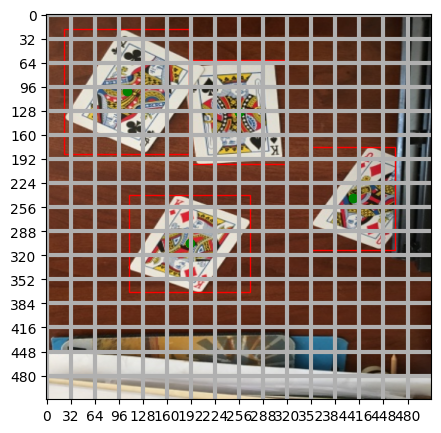

In [40]:
fig, ax = plt.subplots(figsize=(5, 5))
i = 20

img = train_ds[i]["image"].permute(1, 2, 0) * torch.tensor(std).view(
    1, 1, -1
) + torch.tensor(mean).view(1, 1, -1)
bboxes = torch.tensor(train_ds[i]["bboxes"])

ax.imshow(img)
loc = plt.matplotlib.ticker.MultipleLocator(base=32)
ax.xaxis.set_major_locator(loc)
ax.yaxis.set_major_locator(loc)
ax.grid(which="major", axis="both", linestyle="-", linewidth=3)

for bbox in bboxes:
    xmin, ymin, xmax, ymax = bbox[:-1]
    w = xmax - xmin
    h = ymax - ymin
    with_mask = bbox[-1]
    ax.add_patch(Rectangle((xmin, ymin), w, h, fill=False, color="red"))

cx = (bboxes[:, 0] + bboxes[:, 2]) / 2
cy = (bboxes[:, 1] + bboxes[:, 3]) / 2

ax.scatter(cx, cy, color="green", marker="o")

plt.show()

## Задача 3.2. 0.5 балла.

Выход нашей сетки будет несколько больше, чем Bx6x16x16. Почему?

Мы решаем задачу, где классов больше одного. Вспомним прошлое дз: target был одним числом, но выход сетки содержал длинный-длинный вектор, из которого мы получали вероятность принадлежности к тому или иному классу. Здесь то же самое, но как бы в двумерии: у каждой клеточки из этих 16*16 будет свой вектор длины C, который мы будем использовать для определения класса.

Реализуйте обратное относительно collate_fn преобразования, чтобы декодировать выход нейронной сети. Применив функцию decode_prediction к выходу collate function вы должны получить изначальный набор прямоугольников с корректными размерами и координатами, а также классами. Применив к выходу нейросети мы тоже должны получить набор прямоугольников и тоже с корректными классами.

То есть, нужно проделать операции из collate_fn в обратную сторону, но учесть, что у неройнки выход будет чуть длиннее, и там мы должны брать argmax для определения класса.

Hint: в target classes идут в конце. В нейронке они тоже будут в конце, но их будет больше 1. Можно проверять число каналов пришедшего объекта, если оно 6, то перед нами target и надо брать значение, которое записано в клеточке. Иначе (каналов больше 6) перед нами выход нейронки, и надо брать самый вероятный из них.

In [10]:
def decode_prediction(pred, upsample=32, threshold=0.7, return_confidence=False):
    b, c, h, w = pred.shape
    img_w, img_h = w * upsample, h * upsample
    ### YOUR CODE HERE ###
    batch_boxes=[]
    for i in range(b):
      bboxes=[]
      y_cells, x_cells = torch.where(pred[i,4]>=threshold)
      for y,x in zip(y_cells,x_cells):
        x_real=(x+pred[i,0,y,x])*upsample
        y_real=(y+pred[i,1,y,x])*upsample
        w_real=(pred[i,2,y,x])*img_w
        h_real=(pred[i,3,y,x])*img_h
        x_min=x_real-w_real/2
        y_min=y_real-h_real/2
        x_max=x_real+w_real/2
        y_max=y_real+h_real/2
        if c!=6:
          class_id=torch.argmax(pred[i,5:,y,x])
        else:
          class_id=pred[i,5,y,x]
        if return_confidence:
          confidence=pred[i,4,y,x]
          bboxes.append([x_min.item(),y_min.item(),x_max.item(),y_max.item(),confidence,int(class_id)])
        else:
          bboxes.append([x_min.item(),y_min.item(),x_max.item(),y_max.item(),int(class_id)])
      batch_boxes.append(bboxes)
    return batch_boxes

Следующей функцией Вы можете проверить свою реализацию. Проверка не является блокирующей.

In [41]:
def test_decode_predictions() -> None:
    # Применяем collate_fn к некоторым данным
    target1 = [ [ 100, 200, 200, 300, 2 ] ]
    target2 = [ [ 0, 250, 200, 300, 0 ], [ 0, 100, 100, 300, 1 ] ]
    result = collate_fn([
        { 'image': torch.rand((3, 512, 512)), 'bboxes': target1 },
        { 'image': torch.rand((3, 512, 512)), 'bboxes': target2 }
    ])

    target = result['target']
    assert target.shape == (2, 6, 16, 16)
    # В таком виде target соответствует поиску одного класса - 6-ой канал.
    # Добавим еще 2 канала, чтобы проверить работу функции для нескольких классов
    target = torch.cat([ target, torch.zeros(2, 2, 16, 16) ], dim = 1) # Добавляем два канала
    assert target.shape == (2, 8, 16, 16) # Теперь их стало 8

    target[0, 5:, 7, 4] = torch.tensor([ 0.5, 0.6, 0.9 ]) # Это должен быть класс 2
    target[1, 5:, 8, 3] = torch.tensor([ 0.9, 0.6, 0.5 ]) # Это должен быть класс 0
    target[1, 5:, 6, 1] = torch.tensor([ 0.6, 0.9, 0.5 ]) # Это должен быть класс 1

    # Считаем результат
    actual = decode_prediction(target)
    print('Actual:  ', actual)

    # Порядок ббоксов для target2 может меняться в зависимости от вашей реализации и это не ошибка.
    # Скорее всего, он будет такой. Но если ассерт не проходит, попробуйте поменять их местами.
    expected = [ target1, [ target2[1], target2[0] ] ]
    # expected = [ target1, [ target2[0], target2[1] ] ] # <-- такой ответ тоже правильный.
    print('Expected:', expected)

    # Сравниваем
    assert actual == expected

test_decode_predictions()

Actual:   [[[100.0, 200.0, 200.0, 300.0, 2]], [[0.0, 100.0, 100.0, 300.0, 1], [0.0, 250.0, 200.0, 300.0, 0]]]
Expected: [[[100, 200, 200, 300, 2]], [[0, 100, 100, 300, 1], [0, 250, 200, 300, 0]]]


## Задача 3.3. 1 балл.
Реализуйте модель. Первым делом примените первые 4 блока (до layer4 включительно) ResNet50. Далее добавьте несколько блоков (Conv2D, BatchNorm2D, ReLU). Постепенно уменьшайте количество каналов до 5+C, а размер изображения до 16 на 16. Например, 2048 -> 512 -> 128 -> 32 -> 5+C, где С - количество классов в вашем датасете. Размер ядра при этом 3, паддинг 1. Но вариантов много, попробуйте разные! **Последним слоем обязательно должна быть свертка.** Так как все значения, которые мы предсказываем, находятся в отрезке от 0 до 1 (благодаря нормировке с клеточками), мы после финальной свертки еще применим сигмоиду. Для классов в такой постановке это не навредит.

Если будете фантазировать, то для получения правильного размера изображения после сети не стесняйтесь применять слои с фильтрами больше 3.

In [42]:
train_ds[42]['image'].shape
seen=set()
for i in range(len(train_ds)):
  seen.add(train_ds[i]['image'].shape)
seen

{torch.Size([3, 512, 512])}

In [43]:
C = len(train_ds.class_dict)  # Количество классов в вашем датасете, хоть руками посчитайте, хоть подтяните из словаря классов
class Detector(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT) # (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
        #                                                             (fc): Linear(in_features=2048, out_features=1000, bias=True)
        #                                                                   нам нужно все, кроме этих двух слоев
        self.backbone=nn.Sequential( #feature extractor
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4
        )
        out_channels = 5 + C
        self.head=nn.Sequential(
            nn.Conv2d(2048,512,3,1,1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(512,128,3,1,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,32,3,1,1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32,out_channels,3,1,1)
        )
    def forward(self, img):
        x=self.backbone(img)
        x=self.head(x)
        x=torch.sigmoid(x)

        return x

In [44]:
torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 42.8MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [45]:
dummy=torch.rand([1,3,512,512])
Model_test=Detector()
dummy=Model_test(dummy)
print(len(dummy)!=0, dummy.shape)

True torch.Size([1, 11, 16, 16])


## Задача 3.4. 0.5 балла.

Реализуйте функцию потерь.

Для этого:
* Сделайте маску, которая будет говорить о положении детектируемых объектов. Её нужно использовать с помощью masked_select (см. доки PyTorch)
* Лосс похож на оригинальный для Yolo V1 и состоит из 4 частей (reduction='sum' для всех)
    - localization loss - Мы берем MSE по координатам бокса там, где есть детектируемый объект
    - box_loss - MSE от корней ширины и высоты bbox там, где есть детектируемый объект
    - classification_loss - Если детектируемый объект есть, то его кросс-энтропия по его классу
    - confidence_loss - Бинарная кросс-энтропия факта наличия объекта ДЛЯ ВСЕХ пикселей. Делается отдельно для детектируемых объектов (вес 1) и для недетектируемых (вес 0.1 например, поскольку их гораздо больше, но можно экспериментировать)


* Если будете делать описанное выше, то учтите reduction. Бинарная кросс-энтропия вызывается через BCELoss. Параметр C используется для задачи числа классов. Подумайте как зависит индексация от параметра C и используйте его.

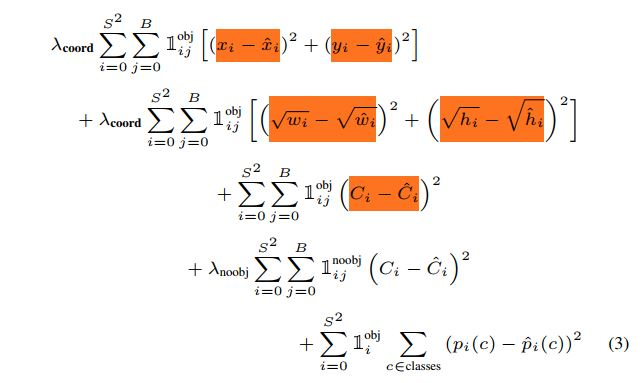

In [46]:
def special_loss(pred, target, C=C):
    ### YOUR CODE HERE ### target[i, :, cy_idx, cx_idx] = torch.stack(
         # [cx_box, cy_box, w_box, h_box, torch.ones_like(cx_box), classes])
    obj_mask=target[:, 4,:,:] > 0
    no_obj_mask=~obj_mask

    pred_x=torch.masked_select(pred[:,0],obj_mask)
    target_x=torch.masked_select(target[:,0],obj_mask)
    pred_y=torch.masked_select(pred[:, 1], obj_mask)
    target_y=torch.masked_select(target[:, 1], obj_mask) # фактически это 1**obj,
    #                                        причем относится и к таргету и к преду

    localization_loss =F.mse_loss(pred_x, target_x, reduction='sum')+F.mse_loss(pred_y, target_y, reduction='sum')

    eps=1e-6 # фактически производная от корня это 1/2(sqrt w)
    pred_w=torch.masked_select(pred[:, 2], obj_mask)
    target_w=torch.masked_select(target[:, 2], obj_mask)
    pred_h=torch.masked_select(pred[:, 3], obj_mask)
    target_h=torch.masked_select(target[:, 3], obj_mask)

    box_loss = F.mse_loss(torch.sqrt(pred_w + eps), torch.sqrt(target_w + eps), reduction='sum') + \
               F.mse_loss(torch.sqrt(pred_h + eps), torch.sqrt(target_h + eps), reduction='sum')
    # if C==6:
    #   pred_classes_obj = pred[:, 5]
    #   target_classes_obj= target[:, 5]
    # else:
    #   pred_classes_obj = pred[:, 5:5+C]
    #   target_classes_obj= target[:, 5:5+C]
    pred_classes=pred[:, 5:5+C]

    # Проверяем, как записаны классы в таргете
    if target.shape[1]==5+C:
        target_classes=target[:, 5:5+C]
    else:
        target_classes_idx=target[:, 5].long()
        target_classes=F.one_hot(target_classes_idx, num_classes=C).float()
        target_classes=target_classes.permute(0, 3, 1, 2)

    pred_classes_obj=torch.masked_select(pred_classes, obj_mask.unsqueeze(1))
    target_classes_obj=torch.masked_select(target_classes, obj_mask.unsqueeze(1))



    classification_loss=F.binary_cross_entropy(pred_classes_obj, target_classes_obj, reduction='sum')
    pred_conf_obj=torch.masked_select(pred[:, 4], obj_mask)
    target_conf_obj=torch.masked_select(target[:, 4], obj_mask)
    conf_loss_obj=F.binary_cross_entropy(pred_conf_obj, target_conf_obj, reduction='sum')

    pred_conf_noobj=torch.masked_select(pred[:, 4], no_obj_mask)
    target_conf_noobj=torch.masked_select(target[:, 4], no_obj_mask)
    conf_loss_noobj=F.binary_cross_entropy(pred_conf_noobj, target_conf_noobj, reduction='sum')

    confidence_loss=conf_loss_obj+0.1*conf_loss_noobj

    return localization_loss + box_loss + classification_loss + confidence_loss

# Задача 4. 1 балла.

Обучите вашу модель (написав цикл обучения), и покажите что она работает (скорее всего, объекты найдутся на 1-2 картинках).

In [47]:
loader = torch.utils.data.DataLoader(train_ds, 10, collate_fn=collate_fn)

In [48]:
batch = next(iter(loader))
for key, value in batch.items():
    print(f"'{key}': {value.shape}")

'image': torch.Size([10, 3, 512, 512])
'target': torch.Size([10, 6, 16, 16])


In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Detector().to(device)
# checkpoint = torch.load('/content/checkpoint_epoch_14.pth', weights_only=False)
# model.load_state_dict(checkpoint['model_state_dict'])
# # model.eval()

In [50]:
import torch
import gc

gc.collect()

torch.cuda.empty_cache()


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
torch.manual_seed(21)
EPOCHS = 15
model = Detector().to(device)
torch.manual_seed(42)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)

for e in tqdm(range(EPOCHS)):
    pbar = tqdm(loader, leave=False)
    epoch_losses = []
    for batch in pbar:
        # keys = list(batch.keys())
        # print(f"Keys in the batch: {keys}")
        # print(batch['target'])
        # break
        image = batch['image'].to(device)
        targets = batch['target'].to(device)
        cx_box = targets[:, 0, :, :]
        cy_box = targets[:, 1, :, :]
        w_box  = targets[:, 2, :, :]
        h_box  = targets[:, 3, :, :]
        if targets.shape[1]!=6:
          class_id=torch.argmax(targets[:,5:])
        else:
          class_id=targets[:,5]
        opt.zero_grad()
        outputs=model(image)
        loss=special_loss(outputs, targets, C)
        loss.backward()
        opt.step()
        epoch_losses.append(loss.item())
    print(f"Epoch {e} done; Train loss {np.mean(epoch_losses):.3f};")
    torch.save({
        'epoch':e,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict':opt.state_dict(),
        'loss': np.mean(epoch_losses)
    }, f'checkpoint.pth')

cuda


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

Epoch 0 done; Train loss 114.480;


  0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 12 done; Train loss 2.851;


  0%|          | 0/33 [00:00<?, ?it/s]

Epoch 13 done; Train loss 3.330;


  0%|          | 0/33 [00:00<?, ?it/s]

Epoch 14 done; Train loss 2.535;


Запустим обученный детектор на тестовых изображениях:

In [52]:
test_loader = torch.utils.data.DataLoader(test_ds, 6, collate_fn=collate_fn)
i = iter(test_loader)
batch = next(i)

In [53]:
model.eval()
images = batch['image'].to(device)


with torch.no_grad():
    outputs = model(images)

preds = outputs.cpu()

/tmp/ipykernel_461/2009817816.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean=torch.tensor(mean).view(1,1,3)
/tmp/ipykernel_461/2009817816.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std=torch.tensor(std).view(1,1,3)


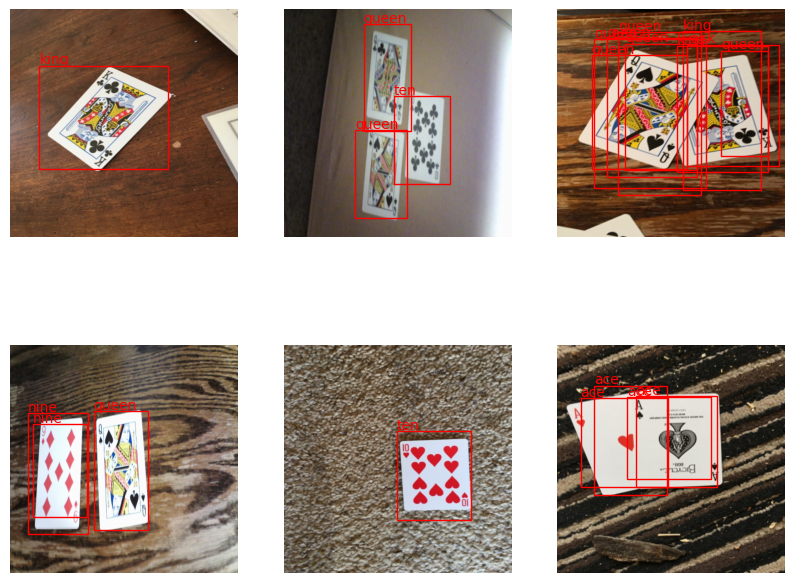

In [57]:
t_bboxes = decode_prediction(preds, upsample=32, threshold=0.1)

for image_boxes in t_bboxes:
    for box in image_boxes:
        class_id = int(box[4])
        box[4] = class_id

visualize(batch['image'], t_bboxes)

Результат сильно так себе, да? Есть множество вариантов улучшений, самый простой из которых это приделать к выходу [NMS](https://paperswithcode.com/method/non-maximum-suppression#:~:text=Non%20Maximum%20Suppression%20is%20a,below%20a%20given%20probability%20bound.). Если хочется, можно почитать про YOLO v1 [тут](https://arxiv.org/abs/1506.02640).

Вроде норм, если повысить до 0.5+ то вщ кайф. При 0.1 чуть больш рамок

# Задача 4 but better (1 балл)

## Прикручиваем NMS :^)

Напомним принцип работы алгоритма:
- Сортируем bbox в порядке убывания уверенности
- Считаем Intersection over Union (IoU) для всех bbox
- Выкидываем все, пересечение с которыми больше порога
- Идем дальше по списку, пока не дойдем до конца

In [58]:
t_bboxes = decode_prediction(preds, upsample=32, threshold=0.1, return_confidence=True)
# [x_min.item(),y_min.item(),x_max.item(),y_max.item(),int(class_id)]

In [59]:
def NMS(bboxes, threshold):
    if len(bboxes)==0:
      return torch.tensor([], dtype=torch.long)
    coords=bboxes[:,:4]
    scores=bboxes[:,4]
    order=torch.argsort(scores, descending=True)
    keep_indices=[]
    while len(order)>0:
      current_index=order[0].item()
      keep_indices.append(current_index)
      if len(order)==1: break
      current_box=coords[current_index]
      rest_indices=order[1:]
      rest_boxes=coords[rest_indices]
      xx1=torch.max(current_box[0], rest_boxes[:, 0])
      yy1=torch.max(current_box[1], rest_boxes[:, 1])
      xx2=torch.min(current_box[2], rest_boxes[:, 2])
      yy2=torch.min(current_box[3], rest_boxes[:, 3])
      w=torch.clamp(xx2-xx1, min=0)
      h=torch.clamp(yy2-yy1, min=0)
      intersection_area=w*h
      current_area=(current_box[2]-current_box[0])*(current_box[3]-current_box[1])
      rest_areas=(rest_boxes[:, 2]-rest_boxes[:, 0])*(rest_boxes[:, 3]-rest_boxes[:, 1])
      union_area=current_area+rest_areas-intersection_area
      iou=intersection_area/union_area
      mask=iou<threshold
      order=rest_indices[mask]

    return torch.tensor(keep_indices, dtype=torch.long)


/tmp/ipykernel_461/2009817816.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean=torch.tensor(mean).view(1,1,3)
/tmp/ipykernel_461/2009817816.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std=torch.tensor(std).view(1,1,3)


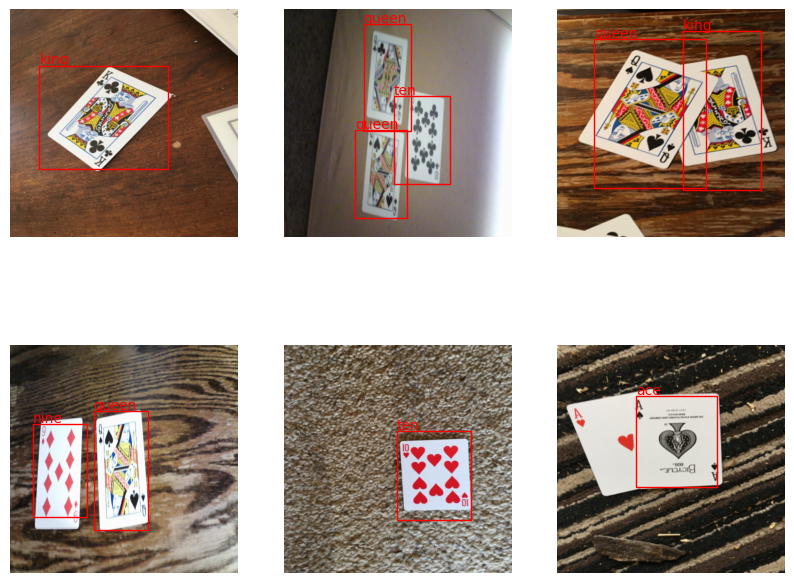

In [60]:
t_bboxes=decode_prediction(preds, upsample=32, threshold=0.1, return_confidence=True)
final_bboxes=[]

for image_boxes in t_bboxes:
    if not image_boxes:
        final_bboxes.append([])
        continue

    boxes_tensor=torch.tensor(image_boxes, dtype=torch.float32)
    keep_indices=NMS(boxes_tensor, threshold=0.2)

    valid_boxes=[]
    for idx in keep_indices.tolist():
        box=image_boxes[idx]
        x_min, y_min, x_max, y_max=box[:4]
        class_id=int(box[5])
        valid_boxes.append([x_min, y_min, x_max, y_max, class_id])
    final_bboxes.append(valid_boxes)

visualize(batch['image'], final_bboxes)

# Задача 5. 3.5 балла.

Займёмся более простыми вещами. Возьмем готовую архитектуру, обучим её на наших данных и посмотрим.

Для этого будем использовать YOLO 11 от ultralytics.

In [18]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 7.3 MB/s eta 0:00:00


## Задача 5.1. 1.5 балла.

Чтобы дальше модель обучалась одной строкой, данные нужно переложить в правильный формат. Да-да, классика перекладывания JSON. Как правильно паковать можно посмотреть [тут](https://roboflow.com/formats/yolov8-pytorch-txt).

Если коротко:
* Есть .yaml, где живут пути к папкам с картинками, количество классов и их названия
* Есть папочки train valid (их поможем вам собрать), в них две подпапки:
    - Первая images, в ней лежат картинки
    - Вторая labels, в ней лежат файлы с названиями как у картинок, но вместо расширения картинок нужен .txt, внутри формат как описан на Roboflow


In [133]:
# !rm -f /content/train/labels.cache
# !rm -f /content/valid/labels.cache

In [13]:
# Делаем папочки
!rm -rf train
!rm -rf valid
!mkdir -p train/images train/labels valid/images valid/labels

Реализуйте функцию, которая принимает аннотации в изначальном формате, а возвращает их в нужном для YOLO 11. Это должен быть массив готовых строк, которые можно сразу забрасывать в файлик, добавив \n.

Использовать сторонние инструменты нельзя, нужно переложить своими руками.

In [25]:
def annotation2txt(bboxes, w_im, h_im):
    ### YOUR CODE HERE ###
    result=[]
    for box in bboxes:
      x_min, y_min, x_max, y_max, class_id = box
      center_x=(x_max+x_min)/(2*w_im)
      center_y=(y_max+y_min)/(2*h_im)
      box_w=(x_max-x_min)/w_im
      box_h=(y_max-y_min)/h_im
      line = f'{int(class_id)} {center_x:.6f} {center_y:.6f} {box_w:.6f} {box_h:.6f}'
      result.append(line)
    return result

In [26]:
# Копируем картиночки по папочкам и создаем txt файлики

for i in range(len(train_ds)):
    result = train_ds.__get_raw_item__(i)

    shutil.copyfile(
        result[0], "./train/images/" + result[0].split("/")[-1],
    )

    h_im, w_im, ch = np.array(Image.open(result[0])).shape
    with open(
        "./train/labels/" + result[0].split("/")[-1].split(".")[0] + ".txt",
        "w",
        encoding="utf8",
    ) as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

for i in range(len(test_ds)):
    result = test_ds.__get_raw_item__(i)

    shutil.copyfile(
        result[0], "./valid/images/" + result[0].split("/")[-1],
    )
    h_im, w_im, ch = np.array(Image.open(result[0])).shape
    with open(
        "./valid/labels/" + result[0].split("/")[-1].split(".")[0] + ".txt",
        "w",
        encoding="utf8",
    ) as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

In [27]:
# Собираем YAML

nc =  len(train_ds.class_dict)
names = [train_ds.class_dict_inv[i] for i in range(nc)]
with open("data.yaml", "w") as f:
    f.write(f"train: ../train/images\nval: ../valid/images\n\nnc: {nc}\nnames: {names}")

## Задание 5.2. 1.5 балла.

Обучите модель YOLO 11 самого маленького размера. Библиотека максимально friendly, от вас требуется написать две строчки. Модель можно взять обученную.

Подсказка: подумайте зачем вам data.yaml и что такое yolo11n.yaml (не стесняйтесь гуглить)

Если у вас лосс NaN или Windows, то есть несколько полезных ссылок (покрывают не все существующие проблемы, но может поможет вам):

https://github.com/ultralytics/ultralytics/issues/1149

https://github.com/ultralytics/yolov5/issues/6907

https://stackoverflow.com/questions/75178762/i-got-nan-for-all-losses-while-training-yolov8-model

In [28]:
from ultralytics import YOLO
device=torch.device("cuda")
### YOUR CODE HERE ###
model=YOLO("yolo11n.pt")
results=model.train(data="data.yaml", epochs=15, device=device, workers=2, amp=False)

Ultralytics 8.4.125 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=Fa

## Задание 5.3. 0.5 балла.

Как-нибудь отрисуйте предсказания на валидационной выборке (хотя бы части из 5-10 картинок).

Здесь можно использовать костыли с параметром save=True у predict, потом прочитать их чем-нибудь, отрисовать матплотлибом. Есть варианты и получше. Дефолтный show будет пытаться показывать через opencv imshow, он в коллабе работать не будет.


0: 640x640 1 king, 1 queen, 5.4ms
1: 640x640 2 kings, 2 jacks, 5.4ms
2: 640x640 2 kings, 1 ace, 1 queen, 5.4ms
3: 640x640 1 king, 1 queen, 5.4ms
4: 640x640 1 nine, 2 queens, 5.4ms
Speed: 2.4ms preprocess, 5.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


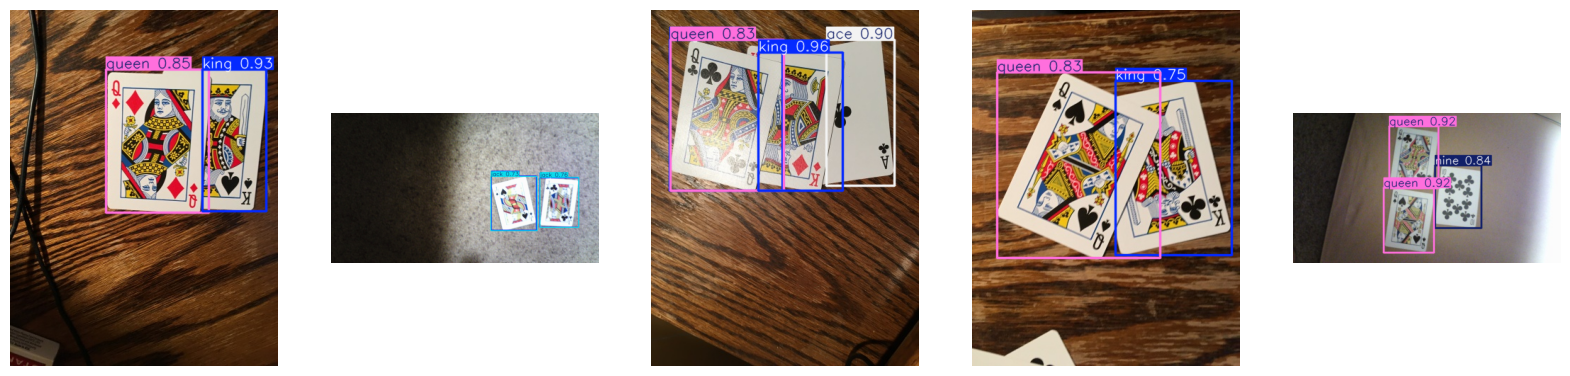

In [61]:
### YOUR CODE HERE ###
import os
import matplotlib.pyplot as plt

model = YOLO('runs/detect/train-3/weights/best.pt')
img_names = os.listdir('./valid/images')[:5]
images=["./valid/images/" + name for name in img_names]
results = model.predict(images)
plt.figure(figsize=(20, 5))
for i, r in enumerate(results):
    plt.subplot(1, 5, i + 1)
    plt.imshow(r.plot()[..., ::-1])
    plt.axis('off')

plt.show()